In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
with open("../saved_models/features.json") as f:
    feature_names = json.load(f)

print("[INFO] Loaded feature list:", len(feature_names))

[INFO] Loaded feature list: 17


In [3]:
DATA_PATH = "../data/processed/featured_dataset.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])

print("[INFO] Dataset loaded:", df.shape)
df.head()


[INFO] Dataset loaded: (43657, 19)


,timestamp,load_actual,temperature,humidity,dew_point,solar_generation,wind_generation,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,load_lag_1,load_lag_24,load_lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168
0,2015-01-07 23:00:00,28222.0,2.2,32,-12.6,52.0,1015.0,23,2,1,0,-0.258819,0.965926,31404.0,25555.0,22734.0,31718.583333,5933.401136,27376.958333
1,2015-01-08 00:00:00,25790.0,0.8,28,-15.6,43.0,1235.0,0,3,1,0,0.000000,1.000000,28222.0,23341.0,22734.0,31820.625000,5802.679387,27395.148810
2,2015-01-08 01:00:00,24481.0,-0.6,25,-18.0,36.0,1443.0,1,3,1,0,0.258819,0.965926,25790.0,22029.0,22734.0,31922.791667,5642.149945,27405.547619
3,2015-01-08 02:00:00,23883.0,-2.5,27,-19.2,36.0,1579.0,2,3,1,0,0.500000,0.866025,24481.0,21456.0,21286.0,32023.916667,5465.376314,27421.005952
4,2015-01-08 03:00:00,23761.0,-3.5,29,-19.2,36.0,1692.0,3,3,1,0,0.707107,0.707107,23883.0,21457.0,20264.0,32119.916667,5289.089097,27441.821429


In [4]:
TARGET = "load_actual"

split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

X_train = train[feature_names]
X_test  = test[feature_names]

y_train = train[TARGET]
y_test  = test[TARGET]


In [5]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [6]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [7]:
svm = SVR(kernel="rbf", C=180, gamma="scale")

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

mae_svm  = mean_absolute_error(y_test, y_pred_svm)
rmse_svm = mean_squared_error(y_test, y_pred_svm) ** 0.5
mape_svm = mean_absolute_percentage_error(y_test, y_pred_svm)

print("SVM Results")
print("MAE :", mae_svm)
print("RMSE:", rmse_svm)
print("MAPE:", mape_svm)


SVM Results
MAE : 333.3472514841154
RMSE: 474.8096315258755
MAPE: 1.1784178881281695


In [8]:
joblib.dump(svm, "../saved_models/svm_model.pkl")
joblib.dump(scaler, "../saved_models/svm_scaler.pkl")

print("[INFO] SVM model and scaler saved")


[INFO] SVM model and scaler saved


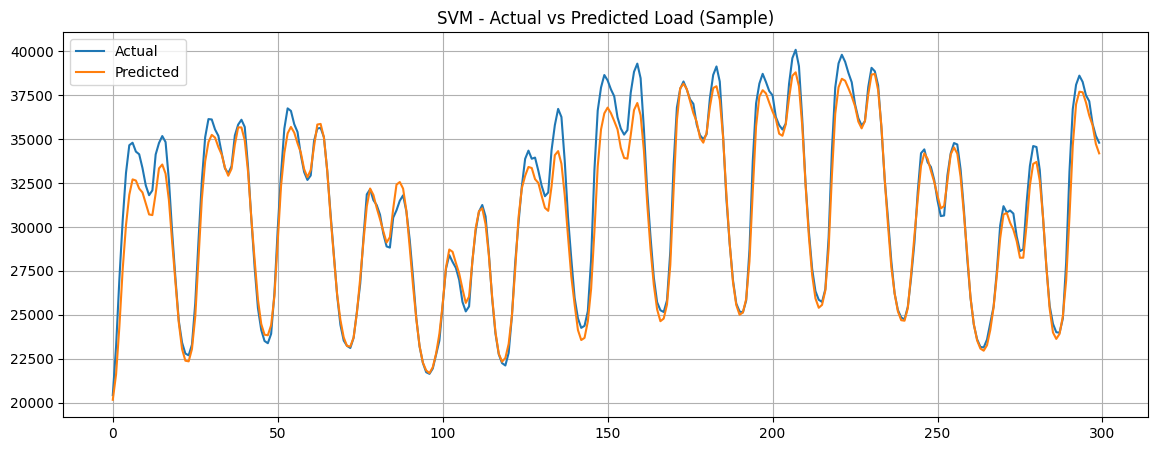

In [9]:
plt.figure(figsize=(14,5))
plt.plot(y_test.values[:300], label="Actual")
plt.plot(y_pred_svm[:300], label="Predicted")
plt.title("SVM - Actual vs Predicted Load (Sample)")
plt.legend()
plt.grid(True)
plt.show()
